# RuFaS ANS344: Dairy Farm Simulation and Analysis

**Course:** ANS344 — Dairy Cattle Management

**Objective:** To understand how changing a key biological parameter (`annual_milk_yield`) affects lactation curves, herd structure, and overall farm productivity using the Ruminant Farm Systems (RuFaS) model.

**Experiment:** We will run two simulations with different `annual_milk_yield` values and compare the results:
1. **High Yield:** 1,300,000 kg (equivalent to 13,000 kg/cow/year for a 100-cow herd)
2. **Low Yield:** 1,100,000 kg (equivalent to 11,000 kg/cow/year for a 100-cow herd)


## Step 1: Set Up the Environment

This first step clones the RuFaS model from its GitHub repository and installs the necessary Python packages to run the simulation.


In [1]:
import os

# Clone the RuFaS-teaching repository (only if not already cloned)
if not os.path.isdir('RuFaS-teaching'):
    !git clone https://github.com/YijingGong/RuFaS-teaching.git

%cd RuFaS-teaching
print('Current directory:', os.getcwd())


Cloning into 'RuFaS-teaching'...
remote: Enumerating objects: 171413, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 171413 (delta 5), reused 17 (delta 4), pack-reused 171387 (from 1)
Receiving objects: 100% (171413/171413), 1.20 GiB | 18.12 MiB/s, done.
Resolving deltas: 100% (117466/117466), done.
Updating files: 100% (854/854), done.
/content/RuFaS-teaching
Current directory: /content/RuFaS-teaching


### Step 1b: Install Dependencies

> ⚠️ **Important:** The next cell will install the required software and then automatically restart the Colab session. This is normal. After the restart, **do not re-run this cell** — just proceed to Step 1c.


In [ ]:
# Install RuFaS and all runtime dependencies
# (pyproject.toml is already configured for Colab compatibility)
!pip install -q .

# Restart the kernel so upgraded numpy/numba/psutil/pandas are loaded
print('Installation complete. Restarting kernel...')
print('After restart: skip this cell, run Step 1c and all cells below.')
import os; os.kill(os.getpid(), 9)


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.4 MB/s eta 0:00:00


### Step 1c: After Restart — Navigate Back and Import Libraries

> ✅ The session has restarted. Now, we navigate back into the `RuFaS-teaching` directory and import all the libraries needed for data analysis and plotting.


In [1]:
import os

# Kernel restart resets the working directory to /content
# Navigate back into the repo
if os.path.isdir('/content/RuFaS-teaching'):
    os.chdir('/content/RuFaS-teaching')
elif os.path.isfile('main.py'):
    pass  # already inside
else:
    raise RuntimeError('Cannot find RuFaS-teaching. Please re-run Step 1 (clone cell) first.')

import json, glob, shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import quad

print('numpy  version:', np.__version__)
import scipy; print('scipy  version:', scipy.__version__)
print('pandas version:', pd.__version__)
import numba; print('numba  version:', numba.__version__)
print()
print('Working directory:', os.getcwd())
print('All libraries imported successfully.')


numpy  version: 2.4.3
scipy  version: 1.15.3
pandas version: 3.0.1
numba  version: 0.64.0

Working directory: /content/RuFaS-teaching
All libraries imported successfully.


---
## Step 2: Set Up the Two Simulation Scenarios

The `annual_milk_yield` parameter is the target for our experiment. The function below creates all the necessary input files for each of our two scenarios (High Yield and Low Yield) by modifying the default RuFaS input files.


In [3]:
def setup_simulation(milk_yield, scenario_label):
    """
    Creates a complete set of simulation input files for a given annual_milk_yield.

    Parameters:
    -----------
    milk_yield : int
        The annual milk yield in kg (e.g., 1300000 for 1.3 million kg)
    scenario_label : str
        A short label for file naming (e.g., '1300k' or '1100k')

    Returns:
    --------
    str : Path to the new task_manager_metadata.json for this scenario
    """

    # --- Step A: Modify the animal.json ---
    original_animal = 'input/data/animal/example_freestall_animal.json'
    new_animal = f'input/data/animal/example_freestall_animal_{scenario_label}.json'

    with open(original_animal, 'r') as f:
        animal_data = json.load(f)
    animal_data['herd_information']['annual_milk_yield'] = milk_yield
    with open(new_animal, 'w') as f:
        json.dump(animal_data, f, indent=4)
    print(f'  [1/3] Created animal JSON: {new_animal}')

    # --- Step B: Modify the dairy metadata to point to the new animal.json ---
    original_dairy_meta = 'input/metadata/example_freestall_dairy_metadata.json'
    new_dairy_meta = f'input/metadata/example_freestall_dairy_metadata_{scenario_label}.json'

    with open(original_dairy_meta, 'r') as f:
        dairy_meta = json.load(f)
    dairy_meta['files']['animal']['path'] = new_animal
    with open(new_dairy_meta, 'w') as f:
        json.dump(dairy_meta, f, indent=4)
    print(f'  [2/3] Created dairy metadata: {new_dairy_meta}')

    # --- Step C: Modify the task.json to point to the new dairy metadata ---
    original_task = 'input/data/tasks/example_freestall_task.json'
    new_task = f'input/data/tasks/example_freestall_task_{scenario_label}.json'

    with open(original_task, 'r') as f:
        task_data = json.load(f)
    task_data['tasks'][0]['metadata_file_path'] = new_dairy_meta
    task_data['tasks'][0]['output_prefix'] = f'freestall_{scenario_label}'
    with open(new_task, 'w') as f:
        json.dump(task_data, f, indent=4)
    print(f'  [3/3] Created task JSON: {new_task}')

    # --- Step D: Create a task_manager_metadata.json for this scenario ---
    original_tm = 'input/task_manager_metadata.json'
    new_tm = f'input/task_manager_metadata_{scenario_label}.json'

    with open(original_tm, 'r') as f:
        tm_data = json.load(f)
    tm_data['files']['tasks']['path'] = new_task
    with open(new_tm, 'w') as f:
        json.dump(tm_data, f, indent=4)
    print(f'  [+]   Created task_manager_metadata: {new_tm}')

    return new_tm


print('Setting up scenario: annual_milk_yield = 1,300,000 kg (13,000 kg/cow × 100 cows)')
tm_1300k = setup_simulation(1300000, '1300k')

print()
print('Setting up scenario: annual_milk_yield = 1,100,000 kg (11,000 kg/cow × 100 cows)')
tm_1100k = setup_simulation(1100000, '1100k')

print()
print('Both scenarios are ready to run.')


Setting up scenario: annual_milk_yield = 1,300,000 kg (13,000 kg/cow × 100 cows)
  [1/3] Created animal JSON: input/data/animal/example_freestall_animal_1300k.json
  [2/3] Created dairy metadata: input/metadata/example_freestall_dairy_metadata_1300k.json
  [3/3] Created task JSON: input/data/tasks/example_freestall_task_1300k.json
  [+]   Created task_manager_metadata: input/task_manager_metadata_1300k.json

Setting up scenario: annual_milk_yield = 1,100,000 kg (11,000 kg/cow × 100 cows)
  [1/3] Created animal JSON: input/data/animal/example_freestall_animal_1100k.json
  [2/3] Created dairy metadata: input/metadata/example_freestall_dairy_metadata_1100k.json
  [3/3] Created task JSON: input/data/tasks/example_freestall_task_1100k.json
  [+]   Created task_manager_metadata: input/task_manager_metadata_1100k.json

Both scenarios are ready to run.


### Step 2b: Run the Simulations

> 🕒 **Note:** Each simulation runs for 5,000 days and will take several minutes to complete.


> ▶️ **Run the two cells below to execute both simulations.** Each takes several minutes.
> Once both show `*** SIMULATION COMPLETED SUCCESSFULLY ***`, proceed to Step 3.


In [8]:
import subprocess, sys, time

def run_rufas(task_manager_path, label):
    print('=' * 60)
    print(f'Running RuFaS simulation: {label}')
    print('=' * 60)
    t_start = time.time()
    result = subprocess.run(
        [sys.executable, 'main.py', '-p', task_manager_path],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    t_end = time.time()
    print(result.stdout)
    if result.returncode != 0:
        print(f'*** SIMULATION FAILED (exit code {result.returncode}) ***')
    else:
        print(f'*** SIMULATION COMPLETED SUCCESSFULLY ***')
    return result.returncode, t_start, t_end

rc_1300k, sim_start_1300k, sim_end_1300k = run_rufas(tm_1300k, 'annual_milk_yield = 1,300,000 kg')


Running RuFaS simulation: annual_milk_yield = 1,300,000 kg
Starting task: TASK MANAGER
RuFaS: Ruminant Farm Systems Model. Version: 1.0.0
Under construction, use the results with caution.
Starting task: 1/1
Finished task: 1/1 with 0 error(s), 212 warning(s), and 398 log(s).
Finished task: TASK_MANAGER with 0 error(s), 124 warning(s), and 35 log(s).


*** SIMULATION COMPLETED SUCCESSFULLY ***


In [9]:
rc_1100k, sim_start_1100k, sim_end_1100k = run_rufas(tm_1100k, 'annual_milk_yield = 1,100,000 kg')


Running RuFaS simulation: annual_milk_yield = 1,100,000 kg
Starting task: TASK MANAGER
RuFaS: Ruminant Farm Systems Model. Version: 1.0.0
Under construction, use the results with caution.
Starting task: 1/1
Finished task: 1/1 with 0 error(s), 212 warning(s), and 398 log(s).
Finished task: TASK_MANAGER with 0 error(s), 124 warning(s), and 35 log(s).


*** SIMULATION COMPLETED SUCCESSFULLY ***


---
## Step 3: Load the Simulation Outputs

Each simulation produces five CSV files in the `output/CSVs/` folder. The cell below finds and loads those files automatically.

> **How file loading works:** The notebook first looks for files with the scenario label in the name (e.g., `freestall_1300k_*`). If those are not found, it falls back to using the timestamps recorded when the simulations ran. If timestamps are also unavailable, it uses the most recently created files. This three-step strategy ensures the notebook works reliably regardless of how Colab names files on a given session.

> **If loading fails:** Make sure both simulations in Step 2b showed `*** SIMULATION COMPLETED SUCCESSFULLY ***`, then re-run this cell.


In [ ]:
import os, glob, time

# ── helper ──────────────────────────────────────────────────────────────────
def _find_by_pattern(pattern):
    """Return the most recently modified file matching a glob pattern, or None."""
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

def _read_csv(path):
    """Read a RuFaS CSV, skipping the disclaimer row (row 0), using row 1 as header."""
    import pandas as pd
    return pd.read_csv(path, header=1, low_memory=False)

# ── Strategy 1: prefix-based (the normal case) ──────────────────────────────
def _load_by_prefix(scenario_label):
    """Load the 5 CSV files for a scenario using its output_prefix."""
    prefix = f'freestall_{scenario_label}'
    csv_dir = 'output/CSVs'
    patterns = {
        'lactation_params': f'{csv_dir}/{prefix}*lactation_parameters*.csv',
        'daily_herd_stats': f'{csv_dir}/{prefix}*daily_herd_statistics*.csv',
        'daily_population': f'{csv_dir}/{prefix}*daily_population*.csv',
        'individual_milk':  f'{csv_dir}/{prefix}*individual_milk*.csv',
        'animal_dmi_pen3':  f'{csv_dir}/{prefix}*animal_DMI_pen3*.csv',
    }
    result, found = {}, 0
    for key, pat in patterns.items():
        f = _find_by_pattern(pat)
        if f:
            result[key] = _read_csv(f)
            found += 1
            print(f'    {key}: {os.path.basename(f)}')
        else:
            result[key] = None
    return result, found

# ── Strategy 2: timestamp-based (fallback if prefix not applied) ─────────────
def _load_by_timestamps(label, t_start, t_end):
    """
    Assign CSV files to a scenario based on when they were written.
    Uses a generous 10-minute window after the simulation ended.
    """
    import pandas as pd
    window_end = t_end + 600          # 10-minute grace window
    all_csvs = glob.glob('output/CSVs/freestall_*.csv')
    # Files written during or just after the simulation run
    in_window = [f for f in all_csvs
                 if t_start - 5 <= os.path.getmtime(f) <= window_end]
    keywords = {
        'lactation_params': 'lactation_parameters',
        'daily_herd_stats': 'daily_herd_statistics',
        'daily_population': 'daily_population',
        'individual_milk':  'individual_milk',
        'animal_dmi_pen3':  'animal_DMI_pen3',
    }
    result, found = {}, 0
    for key, kw in keywords.items():
        matches = [f for f in in_window if kw in f]
        if matches:
            f = max(matches, key=os.path.getmtime)
            result[key] = _read_csv(f)
            found += 1
            print(f'    {key}: {os.path.basename(f)}')
        else:
            result[key] = None
    return result, found

# ── Strategy 3: last-resort (use the N most recent files by keyword) ─────────
def _load_last_resort(rank):
    """
    rank=1 → most recent set of 5 files
    rank=2 → second most recent set (for the other scenario)
    """
    import pandas as pd
    keywords = {
        'lactation_params': 'lactation_parameters',
        'daily_herd_stats': 'daily_herd_statistics',
        'daily_population': 'daily_population',
        'individual_milk':  'individual_milk',
        'animal_dmi_pen3':  'animal_DMI_pen3',
    }
    result, found = {}, 0
    for key, kw in keywords.items():
        all_matches = sorted(
            glob.glob(f'output/CSVs/freestall_*{kw}*.csv'),
            key=os.path.getmtime, reverse=True
        )
        if len(all_matches) >= rank:
            f = all_matches[rank - 1]
            result[key] = _read_csv(f)
            found += 1
            print(f'    {key}: {os.path.basename(f)}')
        else:
            result[key] = None
    return result, found

# ── Main loading logic ───────────────────────────────────────────────────────
print('Locating simulation output files...')
print()
all_csvs = sorted(glob.glob('output/CSVs/freestall_*.csv'))
print(f'  Total freestall_*.csv files found: {len(all_csvs)}')
for f in all_csvs:
    print(f'    {os.path.basename(f)}')
print()

# --- Scenario 1: 1,300,000 kg ---
print('Loading 1,300,000 kg scenario (High Yield):')
data_1300k, found_1300k = _load_by_prefix('1300k')

if found_1300k < 5:
    print(f'  Prefix search found {found_1300k}/5. Trying timestamp fallback...')
    try:
        data_1300k, found_1300k = _load_by_timestamps('1300k', sim_start_1300k, sim_end_1300k)
        print(f'  Timestamp fallback found {found_1300k}/5.')
    except NameError:
        print('  Timestamp variables not available. Using last-resort (most recent files)...')
        data_1300k, found_1300k = _load_last_resort(rank=2)
        print(f'  Last-resort found {found_1300k}/5.')

print()

# --- Scenario 2: 1,100,000 kg ---
print('Loading 1,100,000 kg scenario (Low Yield):')
data_1100k, found_1100k = _load_by_prefix('1100k')

if found_1100k < 5:
    print(f'  Prefix search found {found_1100k}/5. Trying timestamp fallback...')
    try:
        data_1100k, found_1100k = _load_by_timestamps('1100k', sim_start_1100k, sim_end_1100k)
        print(f'  Timestamp fallback found {found_1100k}/5.')
    except NameError:
        print('  Timestamp variables not available. Using last-resort (most recent files)...')
        data_1100k, found_1100k = _load_last_resort(rank=1)
        print(f'  Last-resort found {found_1100k}/5.')

print()
print(f'Summary: High Yield {found_1300k}/5 files | Low Yield {found_1100k}/5 files')
if found_1300k == 5 and found_1100k == 5:
    print('All output files loaded successfully. Proceed to the next step.')
else:
    print()
    print('WARNING: Some files could not be loaded.')
    print('Please make sure both simulations completed successfully (Step 2b),')
    print('then re-run this cell.')


In [11]:
# Quick check: print the raw lactation parameter values
for label, data in [('1,300,000 kg', data_1300k), ('1,100,000 kg', data_1100k)]:
    df = data.get('lactation_params')
    if df is not None:
        print(f'Lactation parameters for {label}:')
        # Show only numeric rows
        numeric_df = df.apply(pd.to_numeric, errors='coerce').dropna(how='all')
        print(numeric_df.to_string())
        print()
    else:
        print(f'WARNING: Lactation parameters not available for {label}.')
        print('Please re-run the simulation and load cells.')


Lactation parameters (Wood model: l, m, n) for 1,300,000 kg scenario:
                                          DISCLAIMER  LactationCurve.__init__.parity_1_lactation_curve_parameter__l (unitless)  LactationCurve.__init__.parity_1_lactation_curve_parameter__m (unitless)  LactationCurve.__init__.parity_1_lactation_curve_parameter__n (unitless)  LactationCurve.__init__.parity_2_lactation_curve_parameter__l (unitless)  LactationCurve.__init__.parity_2_lactation_curve_parameter__m (unitless)  LactationCurve.__init__.parity_2_lactation_curve_parameter__n (unitless)  LactationCurve.__init__.parity_3_lactation_curve_parameter__l (unitless)  LactationCurve.__init__.parity_3_lactation_curve_parameter__m (unitless)  LactationCurve.__init__.parity_3_lactation_curve_parameter__n (unitless)
0  Under construction, use the results with caution.                                                                 17.932983                                                                    0.2297           

---
## Step 4: Lactation Curves (Wood Model)

The **Wood (1967) model** is a widely used mathematical function to describe the lactation curve of dairy cows. It is defined as:

> *y(t) = l × t^m × e^(−n×t)*

Where:
- **y(t)** is the milk yield at day *t* (Days in Milk, DIM)
- **l** is a scaling factor that affects the overall height of the curve
- **m** controls how quickly milk yield rises to its peak
- **n** controls how quickly milk yield declines after the peak

RuFaS calculates these parameters for each parity group based on the `annual_milk_yield` we provided. Let's plot them to see the difference between the two scenarios.


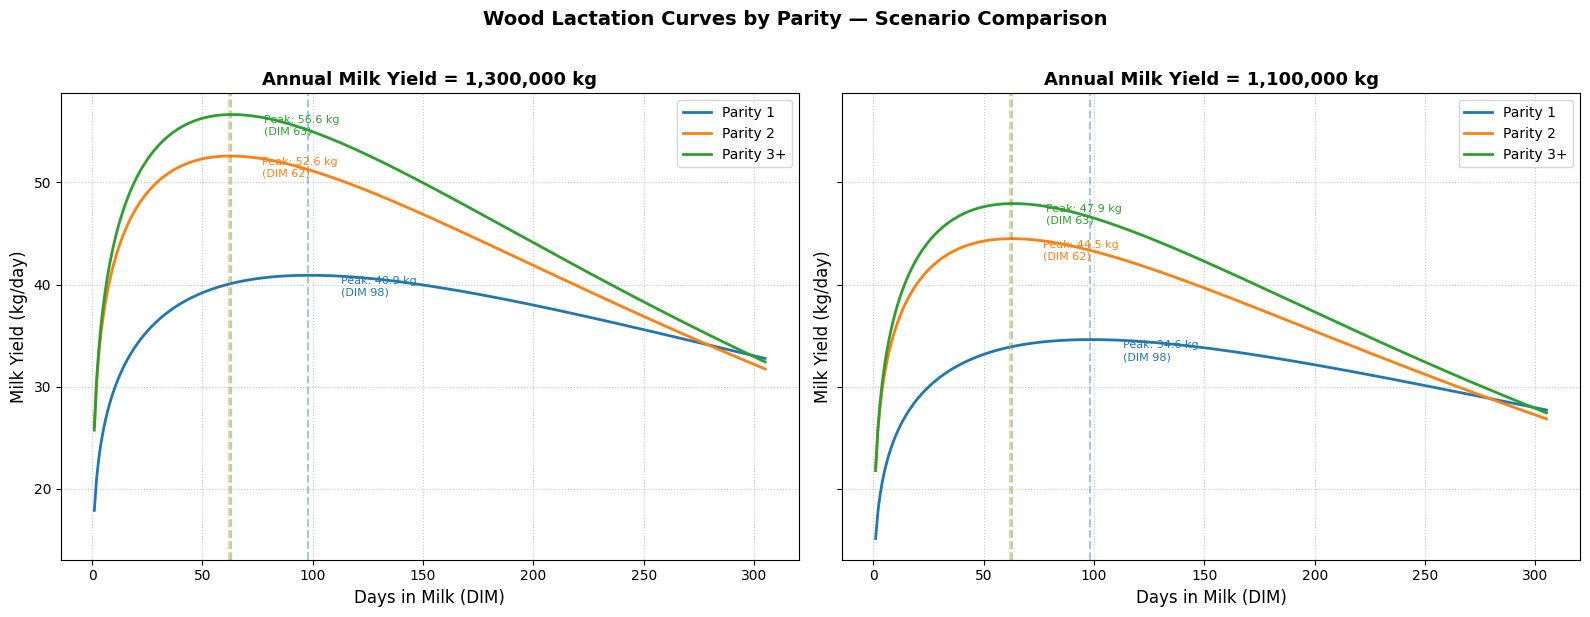

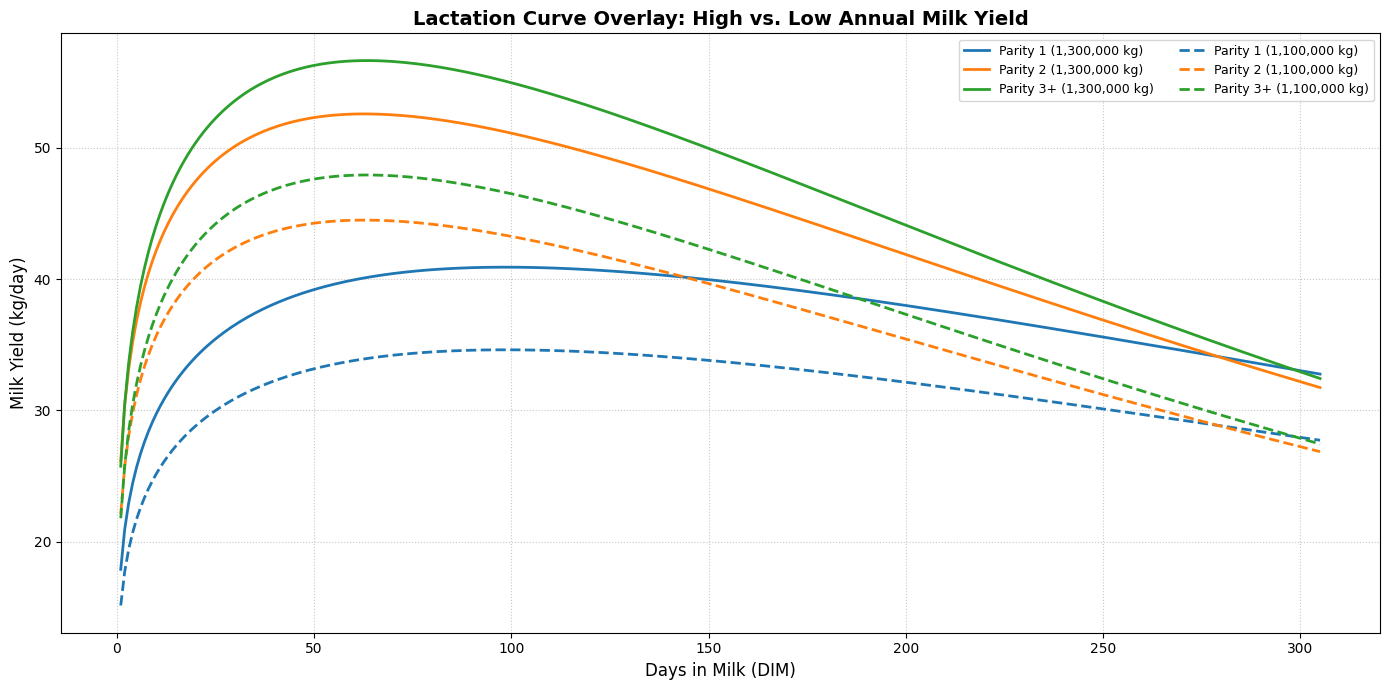


Wood Model Parameters Summary:
Scenario                  Parity     l (scale)       m (ascend)      n (decline)     Peak DIM     Peak Yield (kg/d)
----------------------------------------------------------------------------------------------------
1,300,000 kg              Parity 1   17.9330         0.2297          0.002332        98           40.91
1,300,000 kg              Parity 2   26.2421         0.2214          0.003529        62           52.58
1,300,000 kg              Parity 3+  25.8458         0.2491          0.003928        63           56.64
1,100,000 kg              Parity 1   15.1741         0.2297          0.002332        98           34.61
1,100,000 kg              Parity 2   22.2049         0.2214          0.003529        62           44.49
1,100,000 kg              Parity 3+  21.8695         0.2491          0.003928        63           47.93


In [12]:
def wood_curve(t, l, m, n):
    """Wood (1967) lactation curve model: y = l * t^m * exp(-n*t)"""
    return l * np.power(t, m) * np.exp(-n * t)


def extract_lactation_params(df):
    """
    Extract Wood model parameters (l, m, n) for parities 1, 2, 3
    from the lactation_parameters CSV.
    Returns a dict: {1: (l, m, n), 2: (l, m, n), 3: (l, m, n)}
    """
    params = {}
    for parity in [1, 2, 3]:
        l_col = [c for c in df.columns if f'parity_{parity}_lactation_curve_parameter__l' in c]
        m_col = [c for c in df.columns if f'parity_{parity}_lactation_curve_parameter__m' in c]
        n_col = [c for c in df.columns if f'parity_{parity}_lactation_curve_parameter__n' in c]
        if l_col and m_col and n_col:
            # Use row index 0 (first data row after disclaimer)
            l = float(df[l_col[0]].iloc[0])
            m = float(df[m_col[0]].iloc[0])
            n = float(df[n_col[0]].iloc[0])
            params[parity] = (l, m, n)
    return params


def plot_lactation_curves_comparison(data_high, data_low, label_high='1,300,000 kg', label_low='1,100,000 kg'):
    """
    Plot Wood lactation curves for both scenarios side-by-side,
    and a combined comparison plot.
    """
    t = np.arange(1, 306)  # DIM 1 to 305

    params_high = extract_lactation_params(data_high['lactation_params'])
    params_low  = extract_lactation_params(data_low['lactation_params'])

    colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c'}
    parity_labels = {1: 'Parity 1', 2: 'Parity 2', 3: 'Parity 3+'}

    # --- Figure 1: Side-by-side subplots ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, params, label in [
        (axes[0], params_high, f'Annual Milk Yield = {label_high}'),
        (axes[1], params_low,  f'Annual Milk Yield = {label_low}')
    ]:
        for parity, (l, m, n) in params.items():
            y = wood_curve(t, l, m, n)
            ax.plot(t, y, color=colors[parity], linewidth=2, label=parity_labels[parity])
            # Mark peak
            peak_dim = int(m / n)  # Analytical peak DIM
            peak_yield = wood_curve(peak_dim, l, m, n)
            ax.axvline(x=peak_dim, color=colors[parity], linestyle='--', alpha=0.4)
            ax.annotate(f'Peak: {peak_yield:.1f} kg\n(DIM {peak_dim})',
                        xy=(peak_dim, peak_yield),
                        xytext=(peak_dim + 15, peak_yield - 2),
                        fontsize=8, color=colors[parity])
        ax.set_xlabel('Days in Milk (DIM)', fontsize=12)
        ax.set_ylabel('Milk Yield (kg/day)', fontsize=12)
        ax.set_title(label, fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.7)

    plt.suptitle('Wood Lactation Curves by Parity — Scenario Comparison', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Figure 2: Overlay comparison ---
    fig2, ax2 = plt.subplots(figsize=(14, 7))
    linestyles = {label_high: '-', label_low: '--'}
    for params, label, ls in [
        (params_high, label_high, '-'),
        (params_low,  label_low,  '--')
    ]:
        for parity, (l, m, n) in params.items():
            y = wood_curve(t, l, m, n)
            ax2.plot(t, y, color=colors[parity], linestyle=ls, linewidth=2,
                     label=f'{parity_labels[parity]} ({label})')

    ax2.set_xlabel('Days in Milk (DIM)', fontsize=12)
    ax2.set_ylabel('Milk Yield (kg/day)', fontsize=12)
    ax2.set_title('Lactation Curve Overlay: High vs. Low Annual Milk Yield', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=9, ncol=2)
    ax2.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # --- Print parameter table ---
    print('\nWood Model Parameters Summary:')
    print(f'{"Scenario":<25} {"Parity":<10} {"l (scale)":<15} {"m (ascend)":<15} {"n (decline)":<15} {"Peak DIM":<12} {"Peak Yield (kg/d)"}')
    print('-' * 100)
    for params, label in [(params_high, f'{label_high}'), (params_low, f'{label_low}')]:
        for parity, (l, m, n) in params.items():
            peak_dim = int(m / n)
            peak_yield = wood_curve(peak_dim, l, m, n)
            print(f'{label:<25} {parity_labels[parity]:<10} {l:<15.4f} {m:<15.4f} {n:<15.6f} {peak_dim:<12} {peak_yield:.2f}')


# Run the plot
plot_lactation_curves_comparison(data_1300k, data_1100k)


---
## Step 5: Herd Population Structure Over Time

The `daily_population` output file contains the number of animals in each group (cows, heifers, calves) for every day of the simulation. Plotting this data shows how the herd structure evolves over the simulation period.


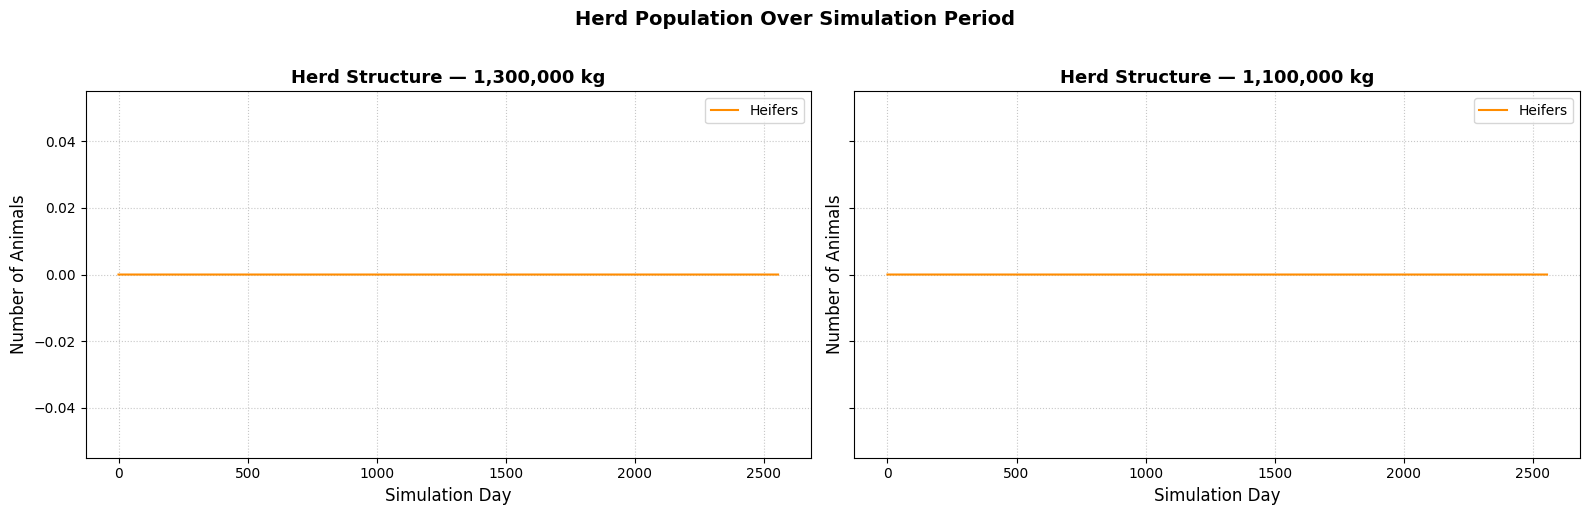

In [13]:
def get_column_by_keyword(df, keyword):
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

def plot_herd_structure(data_high, data_low, label_high='1,300,000 kg', label_low='1,100,000 kg'):
    df_high = data_high['daily_population']
    df_low  = data_low['daily_population']
    if df_high is None or df_low is None:
        print('Daily population data not available.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, df, label in [(axes[0], df_high, label_high), (axes[1], df_low, label_low)]:
        day_col = get_column_by_keyword(df, 'sim_day')
        x_axis = pd.to_numeric(df[day_col], errors='coerce') if day_col else df.index

        # Sum all heifer groups (heiferIs, heiferIIs, heiferIIIs)
        heifer_cols = [get_column_by_keyword(df, 'num_heiferIs'),
                       get_column_by_keyword(df, 'num_heiferIIs'),
                       get_column_by_keyword(df, 'num_heiferIIIs')]
        heifer_cols = [c for c in heifer_cols if c]
        if heifer_cols:
            total_heifers = df[heifer_cols].apply(pd.to_numeric, errors='coerce').sum(axis=1)
            ax.plot(x_axis, total_heifers, label='Heifers (All Stages)', color='darkorange', linewidth=1.5)

        # Total cows (lactating + dry)
        cow_col = get_column_by_keyword(df, 'num_cows_total')
        if cow_col:
            ax.plot(x_axis, pd.to_numeric(df[cow_col], errors='coerce'),
                    label='Cows (Lactating + Dry)', color='steelblue', linewidth=1.5)

        # Calves
        calf_col = get_column_by_keyword(df, 'num_calves')
        if calf_col:
            ax.plot(x_axis, pd.to_numeric(df[calf_col], errors='coerce'),
                    label='Calves', color='forestgreen', linewidth=1.5)

        ax.set_xlabel('Simulation Day', fontsize=12)
        ax.set_ylabel('Number of Animals', fontsize=12)
        ax.set_title(f'Herd Structure — {label}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.7)

    plt.suptitle('Herd Population Over Simulation Period', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_herd_structure(data_1300k, data_1100k)


---
## Step 6: Daily Herd Milk Production

The `daily_herd_statistics` output file contains the total milk produced by the entire herd each day. This is a key indicator of the farm's overall productivity.


In [14]:
def plot_daily_milk_production(data_high, data_low, label_high='1,300,000 kg', label_low='1,100,000 kg'):
    df_high = data_high['daily_herd_stats']
    df_low  = data_low['daily_herd_stats']
    if df_high is None or df_low is None:
        print('Daily herd statistics data not available.')
        return

    day_col_h  = get_column_by_keyword(df_high, 'simulation_day')
    day_col_l  = get_column_by_keyword(df_low,  'simulation_day')
    milk_col_h = get_column_by_keyword(df_high, 'daily_milk_production')
    milk_col_l = get_column_by_keyword(df_low,  'daily_milk_production')

    if not all([day_col_h, day_col_l, milk_col_h, milk_col_l]):
        print('Could not find required columns. Available columns:')
        print(df_high.columns.tolist())
        return

    x_high = pd.to_numeric(df_high[day_col_h], errors='coerce')
    y_high = pd.to_numeric(df_high[milk_col_h], errors='coerce')
    x_low  = pd.to_numeric(df_low[day_col_l],   errors='coerce')
    y_low  = pd.to_numeric(df_low[milk_col_l],  errors='coerce')

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(x_high, y_high, label=f'High Yield ({label_high})', color='steelblue', linewidth=1.5, alpha=0.6)
    ax.plot(x_low,  y_low,  label=f'Low Yield ({label_low})',  color='darkorange', linewidth=1.5, alpha=0.6)

    window = 30
    ax.plot(x_high, y_high.rolling(window).mean(), color='navy',       linewidth=2.5, linestyle='--', label=f'{window}-day avg (High)')
    ax.plot(x_low,  y_low.rolling(window).mean(),  color='saddlebrown', linewidth=2.5, linestyle='--', label=f'{window}-day avg (Low)')

    ax.set_xlabel('Simulation Day', fontsize=12)
    ax.set_ylabel('Herd Milk Yield (kg/day)', fontsize=12)
    ax.set_title('Daily Herd Milk Production: High vs. Low Annual Milk Yield', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print('\nSummary Statistics — Daily Herd Milk Yield (kg/day):')
    print(f'{"Scenario":<25} {"Mean":<12} {"Std":<12} {"Min":<12} {"Max"}')
    print('-' * 70)
    for vals, lbl in [(y_high, label_high), (y_low, label_low)]:
        print(f'{lbl:<25} {vals.mean():<12.1f} {vals.std():<12.1f} {vals.min():<12.1f} {vals.max():.1f}')

plot_daily_milk_production(data_1300k, data_1100k)


milk_yield column not found. Available columns:
['DISCLAIMER', 'AnimalModuleReporter.report_herd_statistics_data.sold_heiferIII_oversupply_num (animals)', 'AnimalModuleReporter.report_herd_statistics_data.bought_heifer_num (animals)', 'AnimalModuleReporter.report_herd_statistics_data.sold_heiferII_num (animals)', 'AnimalModuleReporter.report_herd_statistics_data.cow_herd_exit_num (animals)', 'AnimalModuleReporter.report_herd_statistics_data.sold_cow_num (animals)', 'AnimalModuleReporter.report_herd_statistics_data.GnRH_injection_num_h (injection)', 'AnimalModuleReporter.report_herd_statistics_data.GnRH_injection_num (injection)', 'AnimalModuleReporter.report_herd_statistics_data.PGF_injection_num (injection)', 'AnimalModuleReporter.report_herd_statistics_data.PGF_injection_num_h (injection)', 'AnimalModuleReporter.report_herd_statistics_data.ai_num (AI)', 'AnimalModuleReporter.report_herd_statistics_data.ai_num_h (AI)', 'AnimalModuleReporter.report_herd_statistics_data.preg_check_num (

---
## Step 7: Parity Distribution in the Herd

Understanding the parity structure of the herd is important because higher-parity cows generally produce more milk. The `daily_herd_statistics` output file contains parity-level cow counts for each simulation day.


In [15]:
def plot_parity_distribution(data_high, data_low, label_high='1,300,000 kg', label_low='1,100,000 kg'):
    # Parity data is in daily_herd_stats
    df_high = data_high['daily_herd_stats']
    df_low  = data_low['daily_herd_stats']
    if df_high is None or df_low is None:
        print('Daily herd statistics data not available.')
        return

    parity_cols_h = sorted([c for c in df_high.columns if 'num_cow_for_parity' in c.lower()])
    parity_cols_l = sorted([c for c in df_low.columns  if 'num_cow_for_parity' in c.lower()])

    if not parity_cols_h:
        print('No parity columns found. Available columns:')
        print(df_high.columns.tolist())
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, df, parity_cols, label in [
        (axes[0], df_high, parity_cols_h, label_high),
        (axes[1], df_low,  parity_cols_l, label_low)
    ]:
        day_col = get_column_by_keyword(df, 'simulation_day')
        x_axis = pd.to_numeric(df[day_col], errors='coerce') if day_col else df.index

        y_data = [pd.to_numeric(df[col], errors='coerce') for col in parity_cols]
        labels = [f'Parity {col.split("_")[-1]}' for col in parity_cols]

        ax.stackplot(x_axis, y_data, labels=labels, alpha=0.8)
        ax.set_xlabel('Simulation Day', fontsize=12)
        ax.set_ylabel('Number of Cows', fontsize=12)
        ax.set_title(f'Parity Distribution — {label}', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(True, linestyle=':', alpha=0.7)

    plt.suptitle('Herd Parity Structure Over Simulation Period', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_parity_distribution(data_1300k, data_1100k)


No parity columns found. Showing all available columns:
['DISCLAIMER', 'AnimalModuleReporter.report_daily_animal_population.sim_day (simulation day)', 'AnimalModuleReporter.report_daily_animal_population.num_animals (animals)', 'AnimalModuleReporter.report_daily_animal_population.AnimalType.CALF_deaths (animals)', 'AnimalModuleReporter.report_daily_animal_population.AnimalType.HEIFER_I_deaths (animals)', 'AnimalModuleReporter.report_daily_animal_population.AnimalType.HEIFER_II_deaths (animals)', 'AnimalModuleReporter.report_daily_animal_population.AnimalType.HEIFER_III_deaths (animals)', 'AnimalModuleReporter.report_daily_animal_population.AnimalType.LAC_COW_deaths (animals)', 'AnimalModuleReporter.report_daily_animal_population.AnimalType.DRY_COW_deaths (animals)', 'AnimalModuleReporter.report_daily_animal_population.num_calves (animals)', 'AnimalModuleReporter.report_daily_animal_population.num_heiferIs (animals)', 'AnimalModuleReporter.report_daily_animal_population.num_heiferIIs (a

---
## Step 8: Summary and Discussion Questions

In this experiment, we modified the `annual_milk_yield` parameter in the RuFaS model and observed the following effects:

| Observation | High Yield (1,300,000 kg) | Low Yield (1,100,000 kg) |
|---|---|---|
| Wood parameter `l` (scale) | Higher | Lower |
| Peak milk yield (kg/day) | Higher | Lower |
| Daily herd milk production | Higher | Lower |
| Herd parity structure | Similar | Similar |

### Discussion Questions for Students

1. **What is the biological interpretation of the Wood model parameters `l`, `m`, and `n`?** How does each parameter change between the two scenarios?

2. **Why does parity affect lactation curve shape?** Compare the peak yield and persistency between Parity 1, 2, and 3+ cows.

3. **What management decisions could a farmer make to shift from the low-yield to the high-yield scenario?** Consider genetics, nutrition, and reproduction management.

4. **What are the environmental implications of higher milk production?** Consider feed intake, manure output, and greenhouse gas emissions.

---
*Notebook prepared for ANS344 — Dairy Cattle Management. Model: [RuFaS](https://github.com/YijingGong/RuFaS-teaching)*
